# Brain Tumor Classification

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
from PIL import Image

# Loading Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

train_path = "/content/drive/MyDrive/brain_tumor/Training"
test_path  = "/content/drive/MyDrive/brain_tumor/Testing"

print("TRAINING DATASET")

for cls in os.listdir(train_path):

    cls_path = os.path.join(train_path, cls)

    if os.path.isdir(cls_path):

        print(
            f"{cls}: {len(os.listdir(cls_path))}"
        )

print("\nTESTING DATASET")

for cls in os.listdir(test_path):

    cls_path = os.path.join(test_path, cls)

    if os.path.isdir(cls_path):

        print(
            f"{cls}: {len(os.listdir(cls_path))}"
        )

TRAINING DATASET
meningioma: 1400
pituitary: 1400
glioma: 1400
notumor: 1400

TESTING DATASET
glioma: 400
pituitary: 400
meningioma: 400
notumor: 400


In [4]:
print(os.listdir(train_path))

['meningioma', 'pituitary', 'glioma', 'notumor']


# Data Visualization

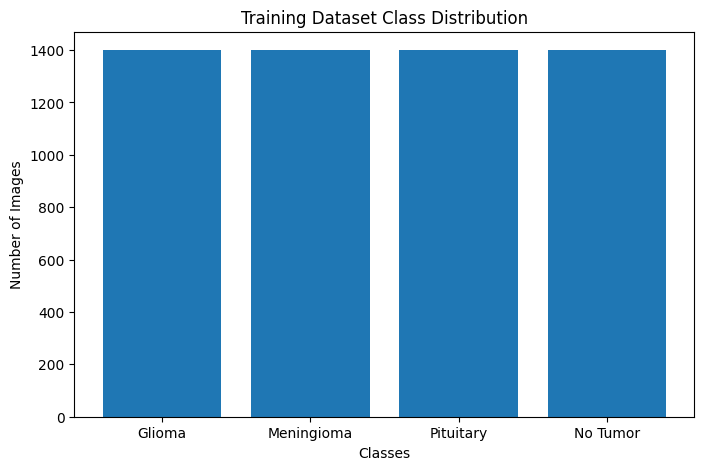

In [5]:
classes = [
    "Glioma",
    "Meningioma",
    "Pituitary",
    "No Tumor"
]

counts = [
    1400,
    1400,
    1400,
    1400
]

plt.figure(figsize=(8,5))

plt.bar(classes, counts)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

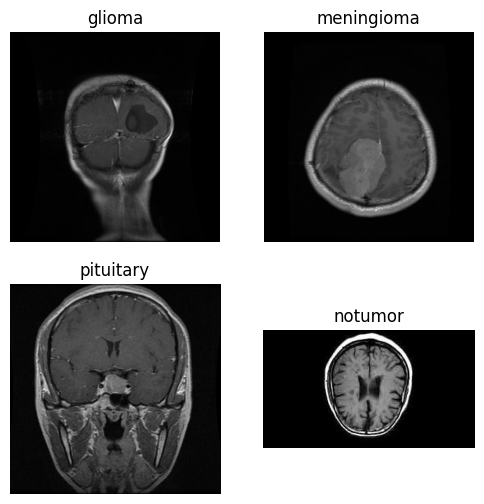

In [6]:
classes = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

plt.figure(figsize=(6,6))

for i, cls in enumerate(classes):

    class_path = os.path.join(train_path, cls)

    image_name = random.choice(
        os.listdir(class_path)
    )

    image_path = os.path.join(
        class_path,
        image_name
    )

    img = Image.open(image_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img, cmap="gray")

    plt.title(cls)

    plt.axis("off")

plt.show()

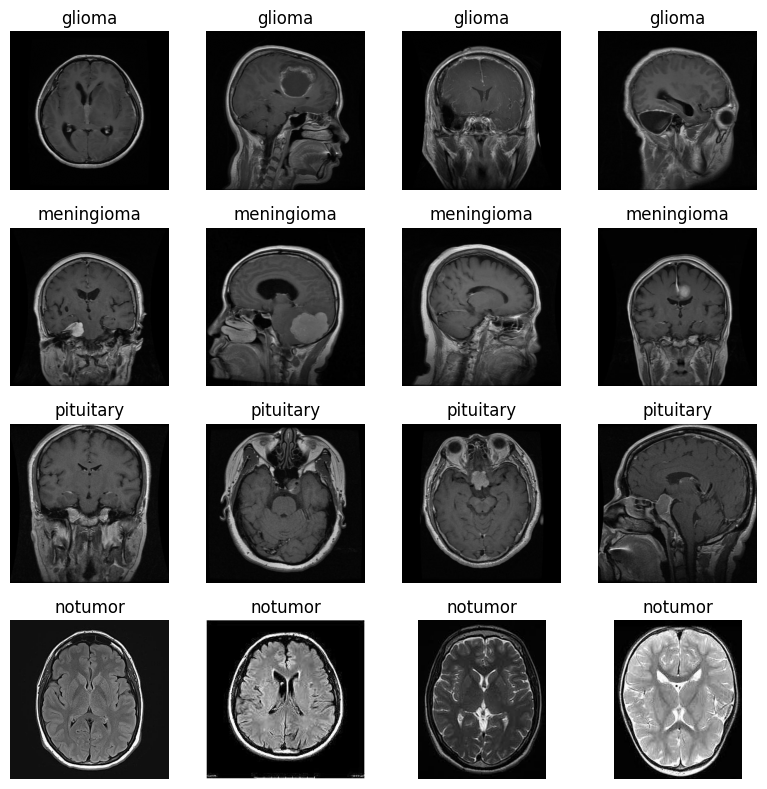

In [7]:
plt.figure(figsize=(8, 8))

plot_num = 1

for cls in classes:

    class_path = os.path.join(train_path, cls)

    # Randomly select 4 images
    image_names = random.sample(
        os.listdir(class_path),
        4
    )

    for image_name in image_names:

        image_path = os.path.join(
            class_path,
            image_name
        )

        img = Image.open(image_path)

        plt.subplot(4, 4, plot_num)

        plt.imshow(img, cmap="gray")

        plt.title(cls)

        plt.axis("off")

        plot_num += 1

plt.tight_layout()
plt.show()

In [8]:
sizes = []

for cls in os.listdir(train_path):

    cls_path = os.path.join(train_path, cls)

    image_name = os.listdir(cls_path)[0]

    image_path = os.path.join(cls_path, image_name)

    img = Image.open(image_path)

    sizes.append(img.size)

    print(f"{cls}: {img.size}")

meningioma: (512, 512)
pituitary: (512, 512)
glioma: (512, 512)
notumor: (393, 400)


In [9]:
sizes=[]
for cls in os.listdir(train_path):

    cls_path = os.path.join(train_path, cls)

    for image_name in os.listdir(cls_path):

        image_path = os.path.join(cls_path, image_name)

        img = Image.open(image_path)

        sizes.append(img.size)

print("Number of unique image sizes:", len(set(sizes)))

print("\nFirst 20 unique sizes:")

for s in list(set(sizes))[:20]:
    print(s)

Number of unique image sizes: 381

First 20 unique sizes:
(491, 624)
(206, 244)
(409, 442)
(503, 369)
(430, 483)
(728, 725)
(201, 251)
(289, 354)
(554, 554)
(236, 226)
(214, 216)
(229, 214)
(733, 781)
(229, 223)
(235, 257)
(411, 501)
(329, 310)
(645, 439)
(434, 512)
(227, 262)


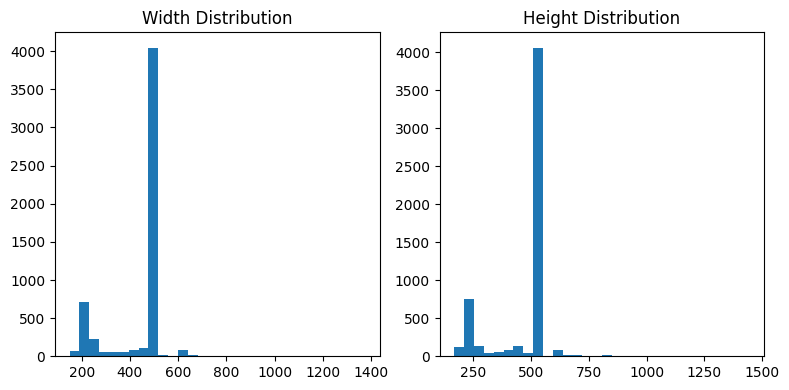

In [10]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title("Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title("Height Distribution")

plt.tight_layout()
plt.show()

# Preparing dataset for training and testing

In [11]:
from torchvision import transforms

transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [12]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root=train_path,
    transform=transform
)

test_dataset = ImageFolder(
    root=test_path,
    transform=transform
)

In [13]:
print(train_dataset.classes)

print(train_dataset.class_to_idx)

['glioma', 'meningioma', 'notumor', 'pituitary']
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [15]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

print(labels[:10])

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([3, 1, 3, 2, 2, 0, 0, 0, 2, 0])


# Model Loading , Training and Testing

In [16]:
from torchvision import models

model = models.densenet121(weights="DEFAULT")

print(model.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 173MB/s]


Linear(in_features=1024, out_features=1000, bias=True)


In [17]:
import torch.nn as nn

for param in model.parameters():

    param.requires_grad = False

model.classifier = nn.Linear(
    model.classifier.in_features,
    4
)

In [18]:
for name, param in model.named_parameters():

    if param.requires_grad:

        print(name)

classifier.weight
classifier.bias


In [19]:
criterion = nn.CrossEntropyLoss()

In [20]:
import torch
import torch.optim as optim

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [21]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

In [22]:
outputs = model(images)
print(outputs.shape)

torch.Size([32, 4])


In [23]:
num_epochs = 5

model.to(device) # Add this line to move the model to the device

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = (
        running_loss /
        len(train_loader)
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {avg_loss:.4f}"
    )

Epoch [1/5] Loss: 0.6602
Epoch [2/5] Loss: 0.3851
Epoch [3/5] Loss: 0.3302
Epoch [4/5] Loss: 0.2926
Epoch [5/5] Loss: 0.2719


In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = 100 * correct / total

print(
    f"Test Accuracy: {accuracy:.2f}%"
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes
    )
)

Test Accuracy: 85.00%

Confusion Matrix:

[[277  78  37   8]
 [ 15 326  36  23]
 [  0   4 396   0]
 [  7  32   0 361]]

Classification Report:

              precision    recall  f1-score   support

      glioma       0.93      0.69      0.79       400
  meningioma       0.74      0.81      0.78       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.92      0.90      0.91       400

    accuracy                           0.85      1600
   macro avg       0.86      0.85      0.85      1600
weighted avg       0.86      0.85      0.85      1600



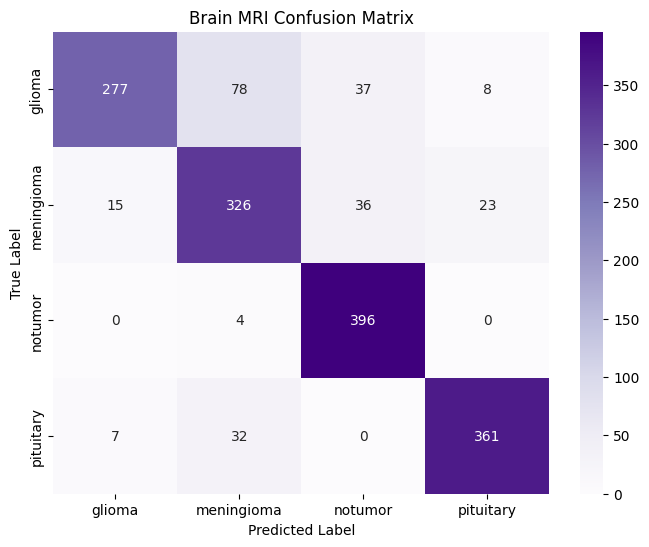

In [25]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.title("Brain MRI Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [26]:
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.features.norm5.parameters():
    param.requires_grad = True

In [27]:
for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

features.denseblock4.denselayer1.norm1.weight
features.denseblock4.denselayer1.norm1.bias
features.denseblock4.denselayer1.conv1.weight
features.denseblock4.denselayer1.norm2.weight
features.denseblock4.denselayer1.norm2.bias
features.denseblock4.denselayer1.conv2.weight
features.denseblock4.denselayer2.norm1.weight
features.denseblock4.denselayer2.norm1.bias
features.denseblock4.denselayer2.conv1.weight
features.denseblock4.denselayer2.norm2.weight
features.denseblock4.denselayer2.norm2.bias
features.denseblock4.denselayer2.conv2.weight
features.denseblock4.denselayer3.norm1.weight
features.denseblock4.denselayer3.norm1.bias
features.denseblock4.denselayer3.conv1.weight
features.denseblock4.denselayer3.norm2.weight
features.denseblock4.denselayer3.norm2.bias
features.denseblock4.denselayer3.conv2.weight
features.denseblock4.denselayer4.norm1.weight
features.denseblock4.denselayer4.norm1.bias
features.denseblock4.denselayer4.conv1.weight
features.denseblock4.denselayer4.norm2.weight
fe

In [28]:
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4
)

In [29]:
train_losses = []

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {avg_loss:.4f}"
    )

Epoch [1/5] Loss: 0.1814
Epoch [2/5] Loss: 0.0578
Epoch [3/5] Loss: 0.0271
Epoch [4/5] Loss: 0.0139
Epoch [5/5] Loss: 0.0102


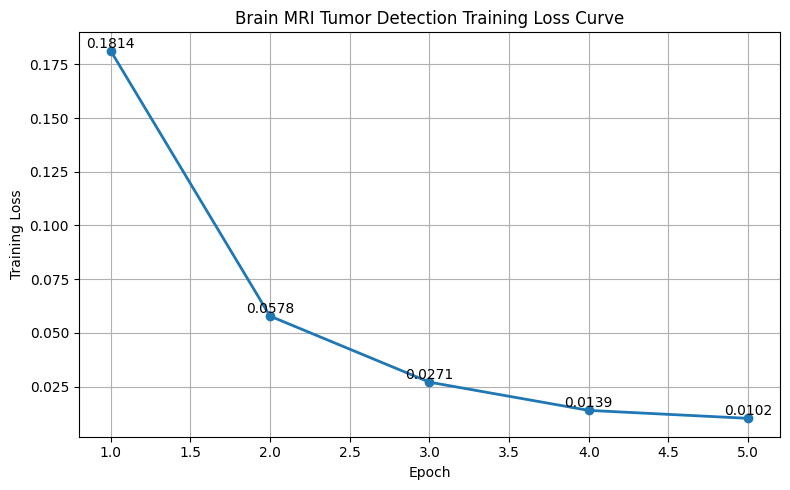

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    marker='o',
    linewidth=2
)

for i, loss in enumerate(train_losses):

    plt.text(
        i + 1,
        loss,
        f"{loss:.4f}",
        ha="center",
        va="bottom"
    )

plt.title(
    "Brain MRI Tumor Detection Training Loss Curve"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.grid(True)

plt.tight_layout()

plt.show()

In [31]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 93.75%


In [32]:
print("Confusion Matrix:\n")
confusion_matrix(all_labels, all_preds)

print("Classification Report:\n")
classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
)

Confusion Matrix:

Classification Report:



'              precision    recall  f1-score   support\n\n      glioma       0.99      0.78      0.87       400\n  meningioma       0.89      0.98      0.93       400\n     notumor       0.93      1.00      0.96       400\n   pituitary       0.96      0.99      0.98       400\n\n    accuracy                           0.94      1600\n   macro avg       0.94      0.94      0.94      1600\nweighted avg       0.94      0.94      0.94      1600\n'

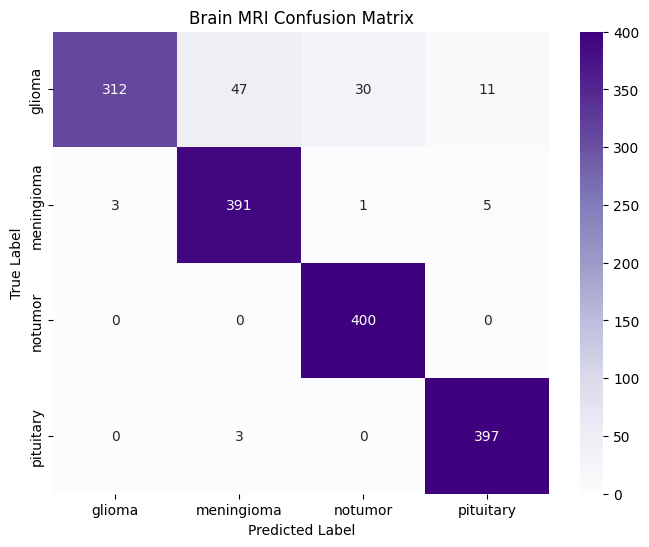

In [33]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.title("Brain MRI Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [34]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch

class_names = [
    'glioma',
    'meningioma',
    'notumor',
    'pituitary'
]

def upload_and_predict():

    uploaded = files.upload()

    image_path = list(uploaded.keys())[0]

    img = Image.open(image_path)

    # Display image
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap="gray")
    plt.title(f"Uploaded MRI: {image_path}")
    plt.axis("off")
    plt.show()

    # Transform
    image = transform(img)

    image = image.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(image)

        probs = torch.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probs, 1)

    print(f"Prediction : {class_names[predicted.item()].upper()}")

    print("\nClass Probabilities:\n")

    for i, cls in enumerate(class_names):

        print(
            f"{cls:<12}: "
            f"{probs[0][i].item()*100:.2f}%"
        )

    print(
        f"\nConfidence: "
        f"{confidence.item()*100:.2f}%"
    )

Saving D-MRI-Image-without-tumor.ppm to D-MRI-Image-without-tumor.ppm


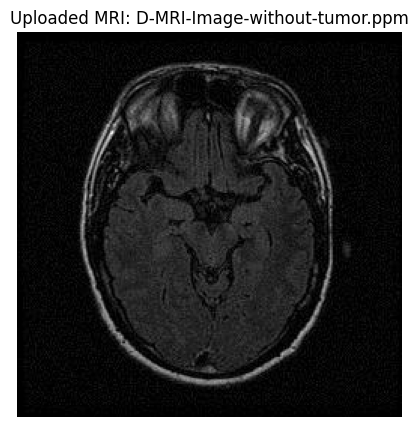

Prediction : NOTUMOR

Class Probabilities:

glioma      : 1.82%
meningioma  : 0.96%
notumor     : 81.66%
pituitary   : 15.56%

Confidence: 81.66%


In [ ]:
upload_and_predict()

Saving glioma.jpg to glioma.jpg


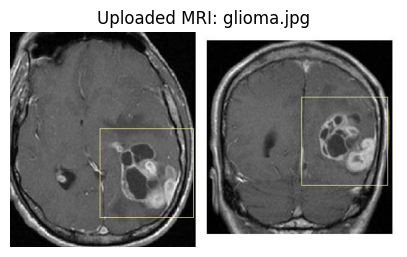

Prediction : GLIOMA

Class Probabilities:

glioma      : 67.70%
meningioma  : 24.55%
notumor     : 5.26%
pituitary   : 2.48%

Confidence: 67.70%


In [ ]:
upload_and_predict()

Saving meningioma.jpg to meningioma.jpg


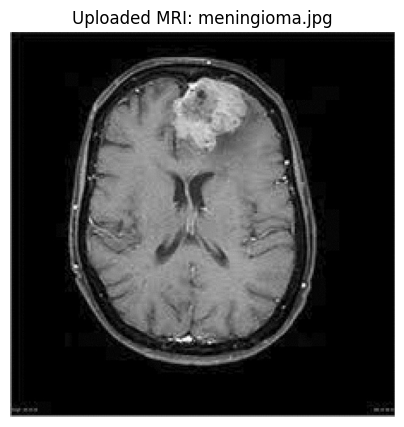

Prediction : MENINGIOMA

Class Probabilities:

glioma      : 0.00%
meningioma  : 97.12%
notumor     : 2.88%
pituitary   : 0.00%

Confidence: 97.12%


In [ ]:
upload_and_predict()

Saving pituitary.jpg to pituitary.jpg


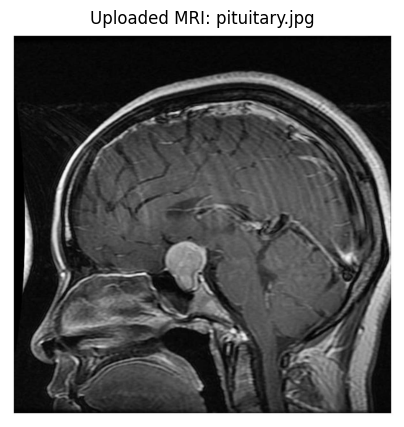

Prediction : PITUITARY

Class Probabilities:

glioma      : 8.28%
meningioma  : 0.19%
notumor     : 1.07%
pituitary   : 90.45%

Confidence: 90.45%


In [ ]:
upload_and_predict()

# Grad-Cam

In [ ]:
import cv2
import numpy as np

In [ ]:
target_layer = model.features.denseblock4

In [ ]:
class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(
            self.save_activation
        )

        self.target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(
        self,
        module,
        input,
        output
    ):

        self.activations = output

    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0]

    def generate_cam(
        self,
        input_tensor,
        class_idx=None
    ):

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()

        output[:, class_idx].backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(
            dim=(1, 2)
        )

        cam = torch.zeros(
            activations.shape[1:],
            device=activations.device
        )

        for i, w in enumerate(weights):

            cam += w * activations[i]

        cam = torch.relu(cam)

        cam = cam.detach().cpu().numpy()

        cam = (
            cam - cam.min()
        ) / (
            cam.max() - cam.min() + 1e-8
        )

        return cam

In [ ]:
class_names = [
    'glioma',
    'meningioma',
    'notumor',
    'pituitary'
]

grad_cam = GradCAM(
    model,
    target_layer
)

def visualize_gradcam(image_path):

    model.eval()

    img = Image.open(image_path).convert("RGB")

    input_tensor = transform(img)

    input_tensor = (
        input_tensor
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        outputs = model(input_tensor)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        pred = probs.argmax(
            dim=1
        ).item()

    cam = grad_cam.generate_cam(
        input_tensor,
        pred
    )

    original = np.array(
        img.resize((224,224))
    )

    cam = cv2.resize(
        cam,
        (224,224)
    )

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = (
        0.5 * original +
        0.5 * heatmap
    ).astype(np.uint8)

    print(
        f"Prediction: {class_names[pred]}"
    )

    print(
        f"Confidence: "
        f"{probs[0,pred].item()*100:.2f}%"
    )

    plt.figure(figsize=(18,6))

    plt.subplot(1,3,1)
    plt.imshow(original)
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.show()

Prediction: glioma
Confidence: 56.74%


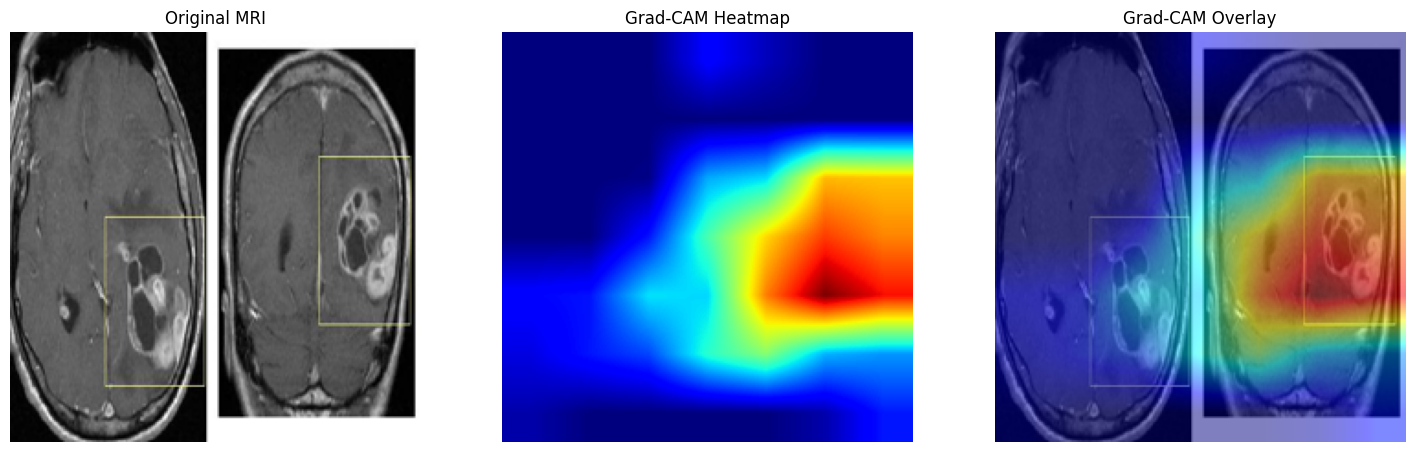

In [ ]:
visualize_gradcam("glioma.jpg")

Prediction: notumor
Confidence: 91.41%


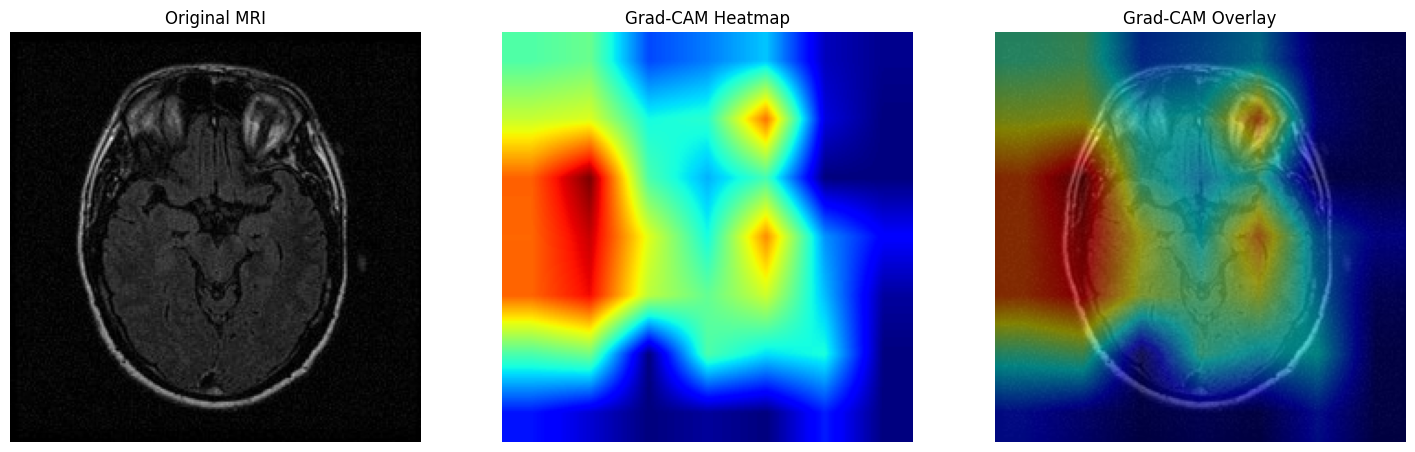

In [ ]:
visualize_gradcam("D-MRI-Image-without-tumor.ppm")

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Prediction: meningioma
Confidence: 98.90%


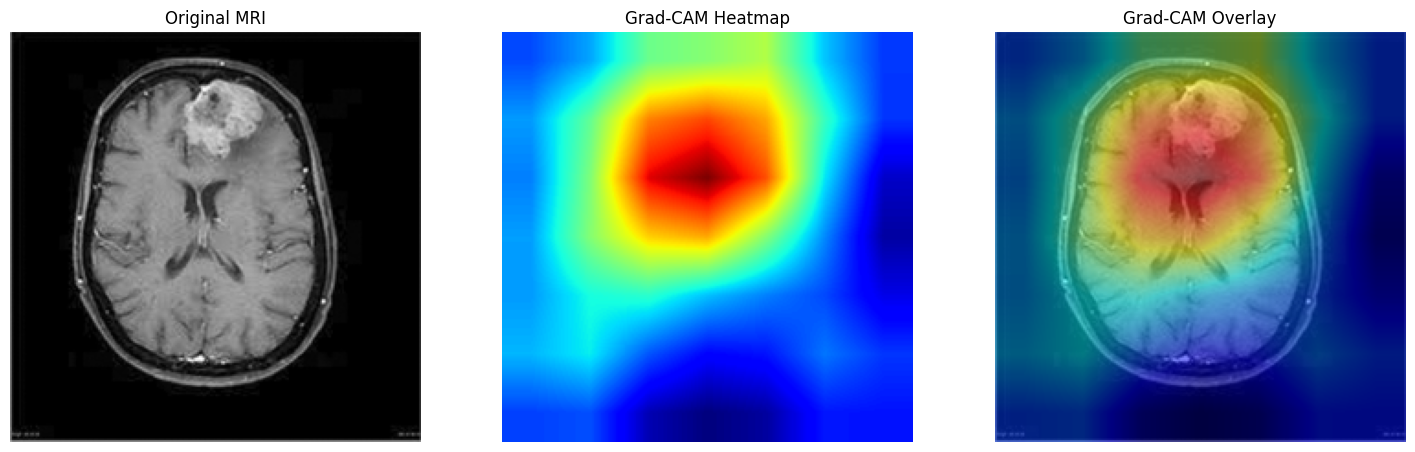

In [ ]:
visualize_gradcam("meningioma.jpg")

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Prediction: pituitary
Confidence: 97.92%


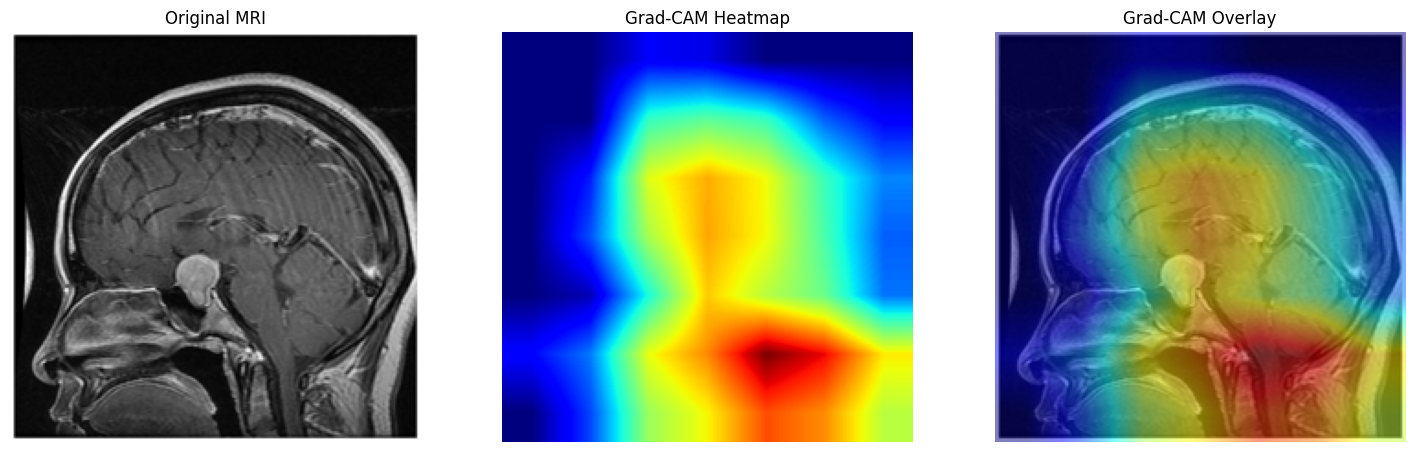

In [ ]:
visualize_gradcam("pituitary.jpg")

In [36]:
torch.save(
    model.state_dict(),
    "brain_mri_densenet121.pth"
)

In [38]:
files.download(
    "brain_mri_densenet121.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>